In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
import torch.nn.functional as F
from monai.losses import DiceCELoss
from segmentation_models_pytorch import create_model
from segmentation_models_pytorch.losses import DiceLoss
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from multistyleseg.data.synthetic.generator import SynthTriangle, Color, AnnotationType
from multistyleseg.experiments.synthetic.train import train_synthetic_model, train_linear_probe
from multistyleseg.data.synthetic.utils import get_dataloader, swap_colors_tensor
from multistyleseg.utils import CKPT_DIR
import matplotlib.pyplot as plt
from pathlib import Path 
from tqdm.auto import tqdm

In [ ]:
N_iterations = 1000
COLORS = (Color.SUBTLE_VAR1, Color.SUBTLE_VAR2)

ckpt_path = CKPT_DIR / "synthetic" / "causal_pathway_model.pth"
ckpt_path.parent.mkdir(parents=True, exist_ok=True)

RETRAIN = False 

RESOLUTION = 256
dataset = SynthTriangle(
    only_triangles=True,
    resolution=RESOLUTION,
    colors=COLORS,
    n_shapes=8,
    fixed_number=True,
    triangle_proportion=1.0,
)
dataloader = get_dataloader(dataset, batch_size=64, num_workers=4)
model = create_model(
    "unet",
    in_channels=3,
    classes=1,
).cuda()
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=N_iterations, eta_min=1e-7)
loss_fn = DiceCELoss(label_smoothing=0.2, include_background=True, sigmoid=True)  # Combined Dice and Cross-Entropy Loss

if ckpt_path.exists() and not RETRAIN:
    model.load_state_dict(torch.load(ckpt_path))
else:
    train_synthetic_model(model=model, dataloader=dataloader, optimizer=optimizer, scheduler=scheduler,criterion=loss_fn,iterations=N_iterations)
    torch.save(model.state_dict(), ckpt_path)

In [3]:
batch = next(iter(dataloader))
model.eval()
image, mask, annotation_type = batch



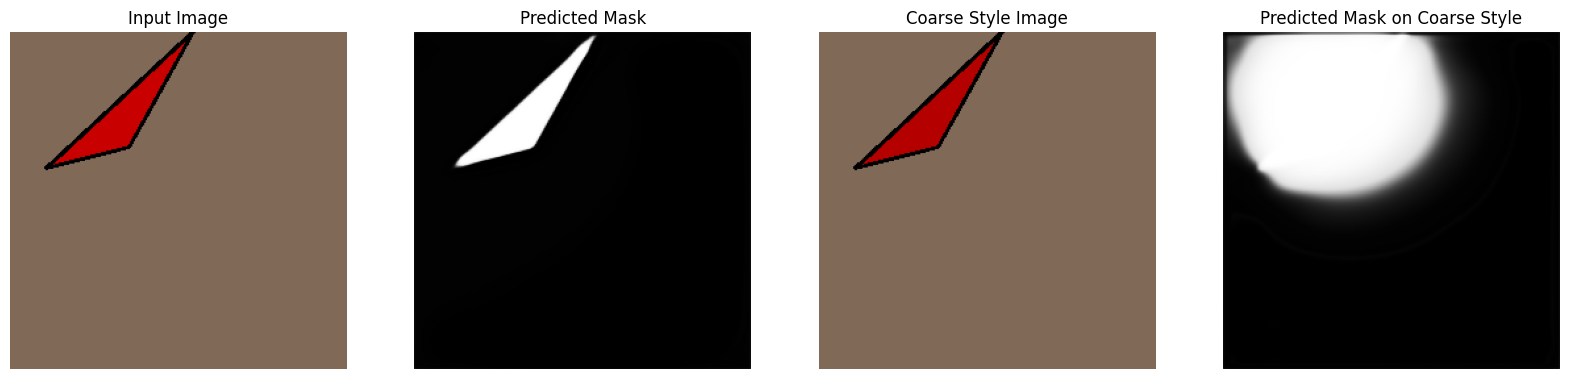

In [4]:
INDEX = 1
coarse_style = swap_colors_tensor(image, color1=COLORS[0], color2=COLORS[1])
fine_style = swap_colors_tensor(coarse_style, color1=COLORS[1], color2=COLORS[0])
with torch.no_grad():
    output_coarse = model(coarse_style.cuda())
    output_sigmoid = torch.sigmoid(output_coarse).cpu().numpy()

    output_fine = model(fine_style.cuda())
    output_fine_sigmoid = torch.sigmoid(output_fine).cpu().numpy()

def normalize(tensor):
    tensor_min = tensor.min()
    tensor_max = tensor.max()
    normalized = (tensor - tensor_min) / (tensor_max - tensor_min + 1e-8)
    return normalized

input_fine = normalize(fine_style.cpu())
input_coarse = normalize(coarse_style.cpu())
fig, axes = plt.subplots(1, 4, figsize=(20, 5))


axes[0].imshow(input_fine[INDEX].cpu().permute(1, 2, 0))
axes[0].set_title("Input Image")

axes[1].imshow(output_fine_sigmoid[INDEX, 0], cmap="gray")
axes[1].set_title("Predicted Mask")

axes[2].imshow(input_coarse[INDEX].cpu().permute(1, 2, 0))
axes[2].set_title("Coarse Style Image")
axes[3].imshow(output_sigmoid[INDEX, 0], cmap="gray")
axes[3].set_title("Predicted Mask on Coarse Style")
for ax in axes:
    ax.axis("off")
plt.show()

Taking 1 fine features and 5 coarse features


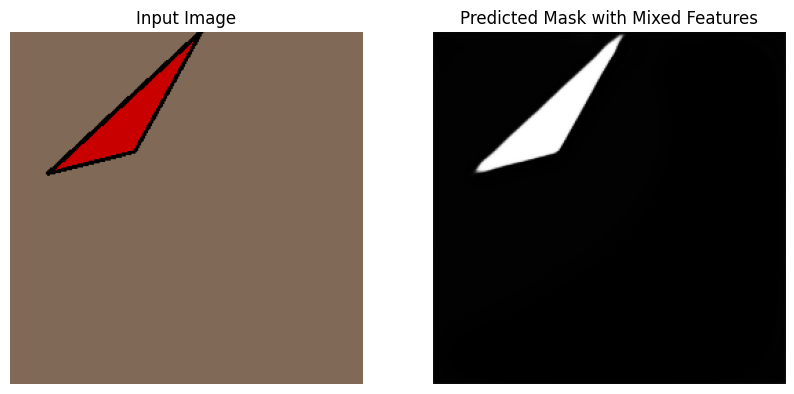

In [5]:
# First check if replacing the encoded features affects the output
fine_features = None
coarse_features = None
FINDEX = 5
INDEX = 1
with torch.no_grad():
    fine_features = model.encoder(fine_style.cuda())
    coarse_features = model.encoder(coarse_style.cuda())
    coarse_features_selected = coarse_features[:FINDEX]
    fine_features_selected = fine_features[FINDEX:]
    print(f"Taking {len(fine_features_selected)} fine features and {len(coarse_features_selected)} coarse features")
    mixed = coarse_features_selected + fine_features_selected 
    output_mixed = model.decoder(mixed)
    output_mixed = model.segmentation_head(output_mixed)
    output_mixed_sigmoid = torch.sigmoid(output_mixed).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(input_fine[INDEX].cpu().permute(1, 2, 0))
axes[0].set_title("Input Image")
axes[1].imshow(output_mixed_sigmoid[INDEX, 0], cmap="gray")
axes[1].set_title("Predicted Mask with Mixed Features")
for ax in axes:
    ax.axis("off")

plt.show()

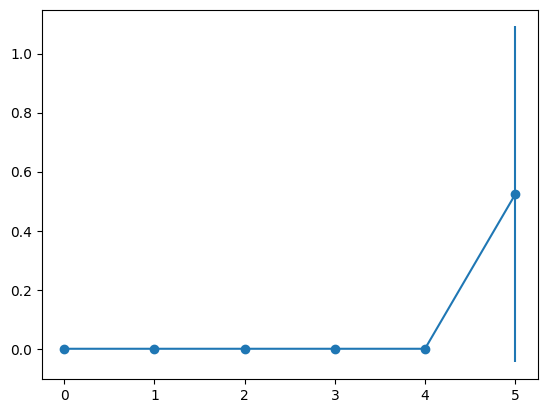

In [6]:
xs = []
ys = []
stds = []
for layer in range(len(fine_features)):
    diff = torch.abs(fine_features[layer] - coarse_features[layer]).flatten(1).median(dim=1)[0]
    mean_diff = diff.mean().item()
    std_diff = diff.std().item()
    xs.append(layer)
    ys.append(mean_diff)
    stds.append(std_diff)
plt.errorbar(xs, ys, yerr=stds, fmt='-o')
plt.show()

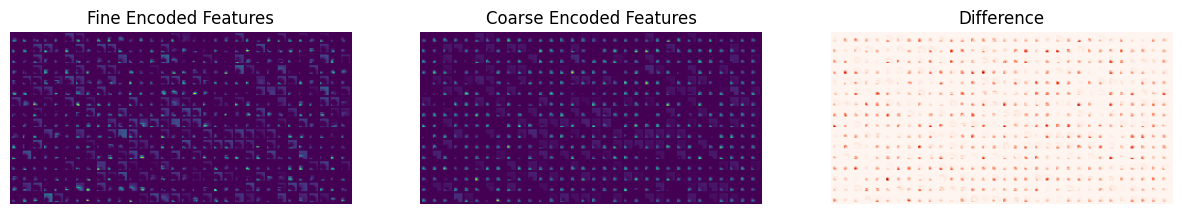

In [7]:
from torchvision.utils import make_grid
INDEX = 0
# For a given image index, plot side by side the fine and coarse features of the last encoder layer
fine_encoded_features = fine_features[-1][INDEX].cpu()
coarse_encoded_features = coarse_features[-1][INDEX].cpu()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
grid_fine = make_grid(fine_encoded_features.unsqueeze(1), nrow=32, normalize=False, scale_each=False).mean(axis=0)
grid_coarse = make_grid(coarse_encoded_features.unsqueeze(1), nrow=32, normalize=False, scale_each=False).mean(axis=0)
diff_grid = torch.abs(grid_fine - grid_coarse)
axes[0].imshow(grid_fine, vmax=grid_fine.max())
axes[0].set_title("Fine Encoded Features")
axes[1].imshow(grid_coarse, vmax=grid_coarse.max())
axes[1].set_title("Coarse Encoded Features")
axes[2].imshow(diff_grid, cmap='Reds')
axes[2].set_title("Difference")
for ax in axes:
    ax.axis("off")
plt.show()

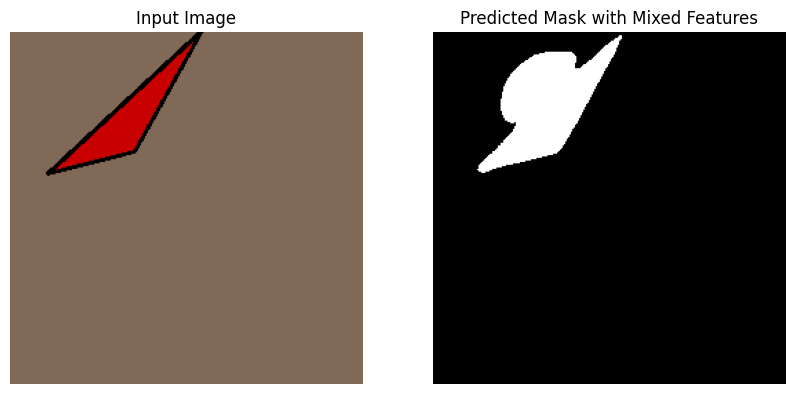

In [8]:
# First check if replacing the encoded features affects the output
fine_features = None
coarse_features = None
FINDEX = 5
INDEX = 1
mixed_features = []
with torch.no_grad():
    fine_features = model.encoder(fine_style.cuda())
    coarse_features = model.encoder(coarse_style.cuda())
    coarse_features_selected = coarse_features[:FINDEX]
    fine_features_selected = fine_features[FINDEX:]

    for i in range(FINDEX, len(fine_features)):
        
        # Compute mean difference for each layer
        # All the features except the ones of INDEX, to avoid leakage
        mask = torch.ones(fine_features[i].shape[0], dtype=bool)
        mask[INDEX] = False
        diff = (fine_features[i][mask] - coarse_features[i][mask]).mean((0, 2,3), keepdim=True)
        mixed_features.append(coarse_features[i] + 3.5*diff)


    combined = coarse_features_selected + mixed_features 
    output_mixed = model.decoder(combined)
    output_mixed = model.segmentation_head(output_mixed)
    output_mixed_sigmoid = torch.sigmoid(output_mixed).cpu().numpy()

# A pretty much perfect fine segmentation. If alpha is increased, a hole starts to appear inside the triangle. If alpha is decreased, the segmentation looks like the coarse one.


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(input_fine[INDEX].cpu().permute(1, 2, 0))
axes[0].set_title("Input Image")
axes[1].imshow(output_mixed_sigmoid[INDEX, 0]> 0.5, cmap="gray")
axes[1].set_title("Predicted Mask with Mixed Features")
for ax in axes:
    ax.axis("off")

plt.show()

In [9]:
# Training a linear probe to predict the style

CLASS_MAPPING = {
    AnnotationType.FINE.value: 1,
    AnnotationType.COARSE.value: 0,
}
probe_path = CKPT_DIR / "synthetic" / "causal_pathway_linear_probe.pth"
if probe_path.exists() and not RETRAIN:
    state_dict = torch.load(probe_path)
    n_out, n_in = state_dict['weight'].shape
    linear_probe = nn.Linear(n_in, n_out).cuda()
    linear_probe.load_state_dict(state_dict)
else:
    linear_probe = train_linear_probe(
        model, dataloader, 5, 250, class_mapping=CLASS_MAPPING)


In [10]:
# 1. Empirical direction (from your working experiment)
with torch.no_grad():
    fine_features = model.encoder(fine_style.cuda())
    coarse_features = model.encoder(coarse_style.cuda())
    LAYER = 5
    empirical_dir = (fine_features[LAYER] - coarse_features[LAYER]).mean((0, 2, 3))  # [C]

# 2. Probe direction (it's just W)
probe_dir = linear_probe.weight.squeeze()  # [C]
# Flip sign if needed to match empirical (coarse→fine)
# Check: if empirical moves toward fine, probe_dir should decrease logit

# 3. Gradient direction
features = coarse_features[LAYER].clone().requires_grad_(True)
pooled = features.mean((2, 3))  # [B, C]
logits = linear_probe(pooled)   # [B, 1]
# Target: low logit (fine)
loss = logits.mean()  # or use BCE with target=0
loss.backward()
grad_dir = features.grad.mean((0, 2, 3))  # [C]

# 4. Compare (use absolute cosine similarity since sign may differ)
cos_emp_probe = F.cosine_similarity(empirical_dir, probe_dir, dim=0).abs()
cos_emp_grad = F.cosine_similarity(empirical_dir, grad_dir, dim=0).abs()
cos_probe_grad = F.cosine_similarity(probe_dir, grad_dir, dim=0).abs()

print(f"Empirical ↔ Probe:    {cos_emp_probe:.4f}")
print(f"Empirical ↔ Gradient: {cos_emp_grad:.4f}")
print(f"Probe ↔ Gradient:     {cos_probe_grad:.4f}")

Empirical ↔ Probe:    0.2161
Empirical ↔ Gradient: 0.2161
Probe ↔ Gradient:     1.0000


In [11]:
# What's in the probe direction that's NOT in the empirical direction?

# Project probe onto empirical
proj_coeff = (probe_dir @ empirical_dir) / (empirical_dir @ empirical_dir)
probe_parallel = proj_coeff * empirical_dir  # Component along style
probe_orthogonal = probe_dir - probe_parallel  # Component orthogonal to style

print(f"Probe magnitude along style axis: {probe_parallel.norm():.4f}")
print(f"Probe magnitude orthogonal to style: {probe_orthogonal.norm():.4f}")

# The orthogonal component is what the probe learned that ISN'T style

Probe magnitude along style axis: 0.1809
Probe magnitude orthogonal to style: 0.8176


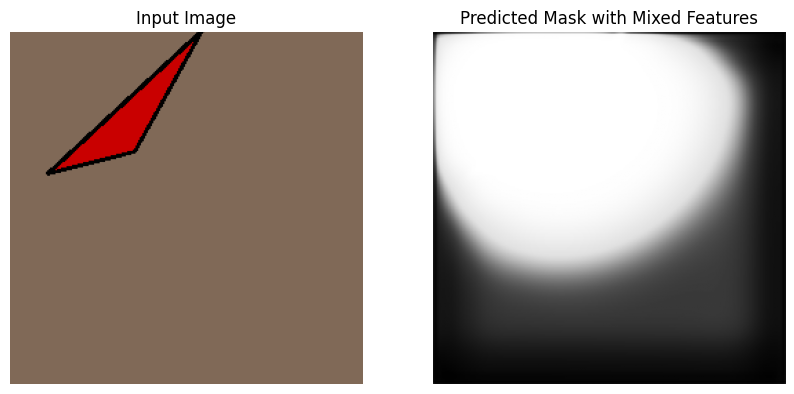

In [12]:
# This should NOT produce clean style transfer
probe_dir_spatial = probe_dir.view(1, -1, 1, 1)
# Try same alpha that worked for empirical
steered = coarse_features[LAYER] + 200 * probe_dir_spatial
# Decode → expect coarse or broken output

with torch.no_grad():
    mixed_features = []
    for i in range(0, len(coarse_features)):
        if i == LAYER:
            mixed_features.append(steered)
        else:
            mixed_features.append(coarse_features[i])
    output_mixed = model.decoder(mixed_features)
    output_mixed = model.segmentation_head(output_mixed)
    output_mixed_sigmoid = torch.sigmoid(output_mixed).cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(input_fine[INDEX].cpu().permute(1, 2, 0))
axes[0].set_title("Input Image")
axes[1].imshow(output_mixed_sigmoid[INDEX, 0] , cmap="gray")
axes[1].set_title("Predicted Mask with Mixed Features")


for ax in axes:
    ax.axis("off")

plt.show()

Adversarial Δf ↔ Empirical: -0.6887
Adversarial Δf ↔ Probe:     0.5432


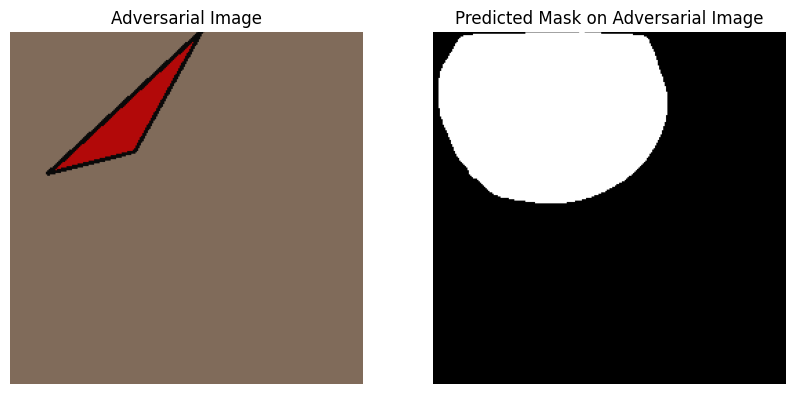

In [13]:
# Original input and features
x_original = coarse_style.cuda()
with torch.no_grad():
    f_original = model.encoder(x_original)[LAYER]

def adversarial_attack(x, target, epsilon=0.1, alpha=0.01, iters=40):
    x_adv = x.clone().detach().requires_grad_(True)

    for i in range(iters):
        features = model.encoder(x_adv)[LAYER]
        pooled = features.mean((2, 3))  # [B, C]
        logits = linear_probe(pooled)   # [B, 1]
        target = target.expand_as(logits)
        loss = F.binary_cross_entropy_with_logits(logits, target)
        loss.backward()
        with torch.no_grad():
            x_adv = x_adv - alpha * x_adv.grad.sign()
            diff = x_adv - x
            x_adv = x_adv + torch.clamp(diff, -epsilon, epsilon)
            x_adv = x_adv.requires_grad_(True)
    return x_adv.detach()

# Apply your adversarial attack to get x_adversarial
x_adversarial = adversarial_attack(x_original, target=torch.tensor([[CLASS_MAPPING[AnnotationType.FINE.value]]]).float().cuda(), epsilon=0.01, alpha=0.01, iters=4)

# Features after attack
with torch.no_grad():
    f_adversarial = model.encoder(x_adversarial)[LAYER]

# Actual feature change caused by adversarial attack
delta_f_adversarial = (f_adversarial - f_original).mean((0, 2, 3))  # [C]

# Now compare to BOTH directions
cos_adv_empirical = F.cosine_similarity(delta_f_adversarial, empirical_dir, dim=0)
cos_adv_probe = F.cosine_similarity(delta_f_adversarial, probe_dir, dim=0)
with torch.no_grad():
    output_adv = model(x_adversarial)
    output_adv_sigmoid = torch.sigmoid(output_adv).cpu().numpy()


print(f"Adversarial Δf ↔ Empirical: {cos_adv_empirical:.4f}")
print(f"Adversarial Δf ↔ Probe:     {cos_adv_probe:.4f}")
x_adversarial = normalize(x_adversarial.cpu())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(x_adversarial[INDEX].cpu().permute(1, 2, 0))
axes[0].set_title("Adversarial Image")


axes[1].imshow(output_adv_sigmoid[INDEX, 0]> 0.5, cmap="gray")
axes[1].set_title("Predicted Mask on Adversarial Image")
for ax in axes:
    ax.axis("off")

plt.show()

In [14]:
input_image = coarse_style.cuda()
encoder = model.encoder
v_features = encoder(input_image)[-1].mean((2, 3))  # [B, C]

# Approximate top singular vectors of J_E via power iteration
def encoder_jacobian_vector_product(v):
    """Compute J_E @ v using forward-mode jvp (returns [B, C])"""
    def f_fn(x):
        return encoder(x)[-1].mean((2, 3))
    # jvp returns (output, jvp). jvp has shape [B, C]
    _, jvp = torch.autograd.functional.jvp(f_fn, (input_image,), (v,), create_graph=True)
    return jvp

def encoder_jacobian_transpose_vector_product(u):
    """Compute J_E^T @ u efficiently (returns input-space tensor same shape as input_image)"""
    x = input_image.clone().detach().requires_grad_(True)
    f = encoder(x)[-1].mean((2, 3))
    loss = (f * u).sum()
    JTu = torch.autograd.grad(loss, x)[0]
    return JTu

# Power iteration for top singular vector
# initialize u with correct feature dimension
feat_dim = v_features.shape[1]
u = torch.randn(feat_dim, device=input_image.device)  # Feature space vector [C]
for _ in tqdm(range(100)):
    encoder.zero_grad()
    v = encoder_jacobian_transpose_vector_product(u)  # Input space tensor
    u = encoder_jacobian_vector_product(v)  # [B, C]
    # aggregate over batch to get a single feature-vector and normalize
    u = u.mean(0)
    u = u / (u.norm() + 1e-12)
    

  0%|          | 0/100 [00:00<?, ?it/s]

In [15]:
print(f"Top singular vector alignment with style: {F.cosine_similarity(u, empirical_dir, dim=0):.4f}")

w = probe_dir
# Compute G @ w approximately
Gw = encoder_jacobian_vector_product(encoder_jacobian_transpose_vector_product(w)).mean(0)

cos_w_d = F.cosine_similarity(w, empirical_dir, dim=0)
cos_Gw_d = F.cosine_similarity(Gw, empirical_dir, dim=0)
print(f"Probe alignment: {cos_w_d:.4f}")
print(f"Gram-transformed probe alignment: {cos_Gw_d:.4f}")

Top singular vector alignment with style: -0.6251
Probe alignment: -0.2161
Gram-transformed probe alignment: -0.6223


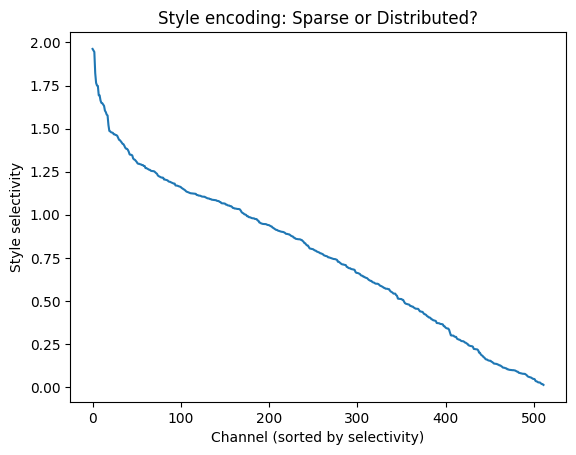

In [16]:
# For each channel, measure style selectivity
def compute_selectivity(fine_features, coarse_features):
    """
    fine_features: [B, C, H, W]
    coarse_features: [B, C, H, W]
    """
    fine_mean = fine_features.mean((0, 2, 3))  # [C]
    coarse_mean = coarse_features.mean((0, 2, 3))  # [C]
    
    selectivity = (fine_mean - coarse_mean).abs()  # [C]
    return selectivity

selectivity = compute_selectivity(fine_features[-1], coarse_features[-1])

# Sort and plot
sorted_selectivity, indices = selectivity.sort(descending=True)
plt.plot(sorted_selectivity.cpu().numpy())
plt.xlabel("Channel (sorted by selectivity)")
plt.ylabel("Style selectivity")
plt.title("Style encoding: Sparse or Distributed?")
plt.show()  

In [17]:
# Zero out top-k most selective channels, measure style transfer quality
def ablate_and_measure(features, selectivity, k, style_direction):
    """Zero out top-k selective channels and measure remaining alignment"""
    top_k_indices = selectivity.argsort(descending=True)[:k]
    
    features_ablated = features.clone()
    features_ablated[:, top_k_indices] = 0
    
    # Measure: can we still do style transfer?
    # Project remaining features onto style direction
    remaining_alignment = F.cosine_similarity(
        features_ablated.mean((0, 2, 3)), 
        style_direction, 
        dim=0
    )
    return remaining_alignment

# Sweep k
for k in [1, 5, 10, 20, 50, 100]:
    remaining = ablate_and_measure(fine_features[-1], selectivity, k, empirical_dir)
    print(f"k={k}: remaining alignment = {remaining:.4f}")

k=1: remaining alignment = 0.1875
k=5: remaining alignment = 0.1517
k=10: remaining alignment = 0.1199
k=20: remaining alignment = 0.0599
k=50: remaining alignment = 0.0221
k=100: remaining alignment = 0.0052


In [18]:

def measure_path_contribution(model, image_A, image_B, layer):
    """
    Measure how much of the style effect flows through a specific layer.
    Patch features at `layer` from B into A's forward pass.
    """
    # Clean forward pass for A
    features_A = model.encoder(image_A)  # List of feature maps
    output_A = model.decoder(features_A)
    
    # Clean forward pass for B
    features_B = model.encoder(image_B)
    output_B = model.decoder(features_B)
    
    # Patched forward pass: A's features except layer, which uses B's
    features_patched = features_A.copy()
    features_patched[layer] = features_B[layer]
    output_patched = model.decoder(features_patched)
    
    # How much did output move toward B's style?
    # Could measure IoU with output_A, output_B
    # Or measure lesion statistics (count, size)
    
    return style_metric(output_patched)

# Sweep over layers
for layer in range(num_layers):
    contribution = measure_path_contribution(model, img_fine, img_coarse, layer)
    print(f"Layer {layer}: style contribution = {contribution}")

NameError: name 'num_layers' is not defined